## **01 - ANÁLISIS EXPLORATORIO (EDA)**

## 1. Carga de datos

Haremos los imports necesarios para disponer de las librerias para tratar los datos correctamente.
Necesitaremos:
  - numpy
  - pandas
  - matplotlib
  - seaborn

In [2]:
import numpy as np 
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt 
import seaborn as sns
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import mean_squared_error, r2_score

Mostramos las tablas para echarles un vistazo

In [3]:
# Ruta del dataset
imdb_file_path = '../data/title.combined.csv'
# Carga del dataset
df = pd.read_csv(imdb_file_path)

## 2. Primer vistazo (forma, tipos, nulos)

**Dimensiones del dataset**

In [4]:
df.shape

(9999, 6)

**Primeras filas del dataset**

In [5]:
df.head()

,title,titleType,genres,numVotes,year,averageRating
0,The Shawshank Redemption,movie,Drama,3185932,1994,9.3
1,The Dark Knight,movie,"Action,Crime,Drama",3165032,2008,9.1
2,Inception,movie,"Action,Adventure,Sci-Fi",2814573,2010,8.8
3,Game of Thrones,tvSeries,"Action,Adventure,Drama",2611980,2011,9.2
4,Breaking Bad,tvSeries,"Crime,Drama,Thriller",2611328,2008,9.5


**Columnas del dataset**

In [6]:
df.columns

Index(['title', 'titleType', 'genres', 'numVotes', 'year', 'averageRating'], dtype='str')

**Tipos de las columnas del dataset**

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   title          9999 non-null   str    
 1   titleType      9999 non-null   str    
 2   genres         9998 non-null   str    
 3   numVotes       9999 non-null   int64  
 4   year           9999 non-null   int64  
 5   averageRating  9999 non-null   float64
dtypes: float64(1), int64(2), str(3)
memory usage: 468.8 KB


**Estadísticas del dataset**

In [8]:
df.describe(include="all")

,title,titleType,genres,numVotes,year,averageRating
count,9999,9999,9998,9.999000e+03,9999.00000,9999.000000
unique,9538,9,465,NaN,NaN,NaN
top,Beauty and the Beast,movie,"Comedy,Drama,Romance",NaN,NaN,NaN
freq,5,8208,382,NaN,NaN,NaN
mean,NaN,NaN,NaN,1.215959e+05,2005.50495,6.849405
std,NaN,NaN,NaN,2.002060e+05,16.87822,1.046733
min,NaN,NaN,NaN,2.017100e+04,1902.00000,1.000000
25%,NaN,NaN,NaN,3.065550e+04,1999.00000,6.200000
50%,NaN,NaN,NaN,5.417300e+04,2010.00000,6.900000
75%,NaN,NaN,NaN,1.228770e+05,2018.00000,7.600000


**Valores ausentes del dataset**

In [9]:
df.isna().sum()

title            0
titleType        0
genres           1
numVotes         0
year             0
averageRating    0
dtype: int64

Hay 1 valor nulo entre los géneros habrá que decidir que hacer con él cuando se haga la limpieza.

**Valores duplicados del dataset**

In [10]:
df.duplicated().sum()

np.int64(0)

No hay valores duplicados.

## 3. Variable objetivo: la nota

**Distribución de la nota media a lo largo del dataset**

In [11]:
df["averageRating"].describe()

count    9999.000000
mean        6.849405
std         1.046733
min         1.000000
25%         6.200000
50%         6.900000
75%         7.600000
max         9.800000
Name: averageRating, dtype: float64

<Axes: >

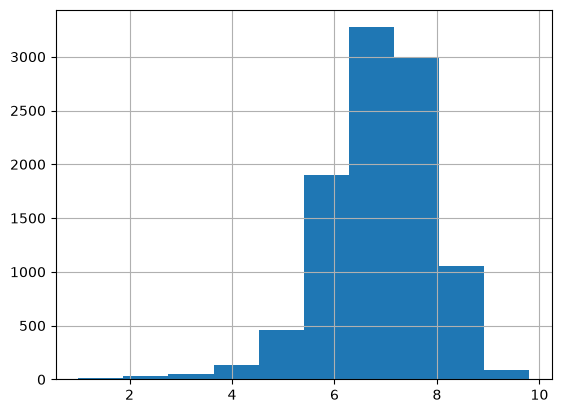

In [12]:
df["averageRating"].hist()

## 4. Features candidatas (géneros, años, votos, tipo)

**Distribución del número de votos a lo largo del dataset**

In [13]:
df["numVotes"].describe()

count    9.999000e+03
mean     1.215959e+05
std      2.002060e+05
min      2.017100e+04
25%      3.065550e+04
50%      5.417300e+04
75%      1.228770e+05
max      3.185932e+06
Name: numVotes, dtype: float64

**Conteo de géneros**

In [16]:
df_split=df["genres"].str.split(",")
df_split.explode().value_counts()
# df["genres"].str.split(",").explode().value_counts()

genres
Drama          5595
Comedy         3499
Action         2730
Crime          2146
Adventure      2012
Thriller       1521
Romance        1410
Mystery        1232
Horror         1175
Animation       805
Fantasy         776
Sci-Fi          735
Biography       677
Family          493
History         352
Music           253
Sport           202
Documentary     183
War             176
Musical         114
Western          86
Film-Noir        34
Short            28
Reality-TV       16
Game-Show         9
Talk-Show         8
News              5
Name: count, dtype: int64

## 5. Conclusiones del EDA

Con lo que hemos probado a lo largo del notebook vamos a plantearnos varias preguntas.

¿Realmente la nota sirve como objetivo? ¿Hay una diferencia aprovechable entre una peli de 6.2 y una de 7.6?

1. **Escala**. Nota va sobre 10 y vemos que las notas van del 1.0 al 9.8, por lo que se usa casi toda la escala posible.
2. **Centro**. Media de 6.85 y Mediana de 6.9. Son casi idénticas. (Distribución simétrica, no arrastrada hacia un lado)
3. **Dispersión**. std=1.05. La mayoría de las notas viven entre 5.8 (6.85-1.05) y 7.9 (6.85+1.05), lo cual es un recorrido lo suficientemente amplio como para analizarlo. Además, los cuartiles lo confirman, el 50% central se encuentra entre el 6.2 (25%) y el 7.6 (75%). 
4. **Forma**. A partir del diagrama de antes podemos ver que el pico se genera entre el 6.5 y el 7 aproximadamente, por lo que se genera una campana sana con colas en ambos lados.
5. **Valores raros**. No hay ningún valor negativo ni ningún valor que supere el 10, por lo que no hay valores raros.

En conclusión, la nota tiene recorrido suficiente, ya que hay una diferencia aprovechable entre un 6.2 y un 7.6 para que un modelo aprenda.

Por tanto, ***averageRating*** será el objetivo del **Módulo A** (regresión), y descartamos la predicción de votos, ya que no aporta nada relevante.

En cuanto al **Módulo B**, el recomendador, este se hará por similitud sobre las features estructuradas (géneros, año, votos...). 

También se contemplaba un recomendador por similitud semántica de la sinopsis (embeddings). Al inspeccionar el dataset se confirma que no existe ninguna columna de texto (ni sinopsis ni reparto ni dirección): solo título, tipo, géneros, votos, año y nota. En el futuro se valorará una posible ampliación del dataset actual para poder implementar esta mejora.